# Weather Data for Substation Load Forecasting

This notebook demonstrates how to access, prepare, and align weather data for use as features in the substation load forecasting model built in **`forecasting.ipynb`**.

## Why Weather Data?

Substation load is strongly influenced by weather:
- **Temperature** drives heating/cooling demand (the dominant weather effect on UK load)
- **Solar irradiance** affects embedded solar PV generation, reducing net demand
- **Wind speed** correlates with embedded wind generation and affects heat loss from buildings

## Data Source

We use the [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api), which provides free access to ERA5 reanalysis data without requiring registration. For production use, the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu/) offers the full ERA5 dataset.

## Contents
1. Setup & Configuration
2. Define Location & Time Period
3. Fetch Historical Weather Data
4. Explore & Visualise
5. Feature Engineering for Forecasting
6. Export for Use in Forecasting Notebook

In [1]:
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore")

# Visualisation style (consistent with forecasting.ipynb)
COLORS = {
    "temperature": "#dc322f",
    "wind": "#268bd2",
    "solar": "#b58900",
    "primary": "#1f4e79",
    "secondary": "#6c757d",
}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

print("Imports successful.")

Imports successful.


---
## 2. Define Location & Time Period

We match the Brighton Local 33kV substation and date range used in `forecasting.ipynb`.

In [2]:
# Brighton Local 33kV substation coordinates (approximate)
LATITUDE = 50.82
LONGITUDE = -0.14
LOCATION_NAME = "Brighton Local 33kV"

# Match the forecasting notebook date range
START_DATE = "2024-01-01"
END_DATE = "2024-03-31"  # Open-Meteo uses inclusive end date

print(f"Location: {LOCATION_NAME} ({LATITUDE}°N, {LONGITUDE}°E)")
print(f"Period:   {START_DATE} to {END_DATE}")

Location: Brighton Local 33kV (50.82°N, -0.14°E)
Period:   2024-01-01 to 2024-03-31


---
## 3. Fetch Historical Weather Data

We use the [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) which serves ERA5 reanalysis data. This is the same ERA5 dataset available from Copernicus CDS, but accessible without registration.

### Variables requested
| Variable | ERA5 name | Relevance |
|---|---|---|
| `temperature_2m` | 2m temperature | Heating/cooling demand |
| `relative_humidity_2m` | 2m relative humidity | Perceived temperature |
| `wind_speed_10m` | 10m wind speed | Embedded wind generation |
| `wind_direction_10m` | 10m wind direction | Wind farm orientation |
| `shortwave_radiation` | Surface solar radiation | Embedded PV generation |
| `direct_radiation` | Direct solar radiation | PV panel output |
| `diffuse_radiation` | Diffuse solar radiation | Overcast PV output |
| `cloud_cover` | Total cloud cover | Solar proxy |
| `precipitation` | Total precipitation | Behavioural patterns |

In [3]:
# Fetch hourly weather data from Open-Meteo Historical API
HOURLY_VARIABLES = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "cloud_cover",
    "precipitation",
]

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join(HOURLY_VARIABLES),
    "timezone": "Europe/London",
}

print(f"Requesting {len(HOURLY_VARIABLES)} hourly variables from Open-Meteo...")
response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
data = response.json()

print(f"Response received: {len(data['hourly']['time'])} hourly records")
print(f"Elevation: {data.get('elevation', 'N/A')} m")
print(f"Timezone: {data.get('timezone', 'N/A')}")

Requesting 9 hourly variables from Open-Meteo...
Response received: 2184 hourly records
Elevation: 22.0 m
Timezone: Europe/London


In [4]:
# Parse into a pandas DataFrame
hourly = data["hourly"]
weather_df = pd.DataFrame(hourly)
weather_df["time"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.set_index("time")
weather_df.index.name = "timestamp"

print(f"DataFrame shape: {weather_df.shape}")
print(f"Date range: {weather_df.index.min()} to {weather_df.index.max()}")
print(f"Frequency: {pd.infer_freq(weather_df.index)}")
print(f"\nMissing values per column:")
print(weather_df.isna().sum())
print(f"\nFirst few rows:")
weather_df.head()

DataFrame shape: (2184, 9)
Date range: 2024-01-01 00:00:00 to 2024-03-31 23:00:00
Frequency: h

Missing values per column:
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
wind_direction_10m      0
shortwave_radiation     0
direct_radiation        0
diffuse_radiation       0
cloud_cover             0
precipitation           0
dtype: int64

First few rows:


,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,direct_radiation,diffuse_radiation,cloud_cover,precipitation
timestamp,,,,,,,,,
2024-01-01 00:00:00,8.4,74,34.2,258,0.0,0.0,0.0,63,0.0
2024-01-01 01:00:00,8.9,69,31.1,265,0.0,0.0,0.0,46,0.0
2024-01-01 02:00:00,8.3,73,33.3,264,0.0,0.0,0.0,44,0.0
2024-01-01 03:00:00,7.6,76,30.5,263,0.0,0.0,0.0,37,0.0
2024-01-01 04:00:00,7.7,75,29.6,267,0.0,0.0,0.0,91,0.0


In [5]:
# Summary statistics
print("Weather Data Summary Statistics")
print("=" * 60)
weather_df.describe().round(2)

Weather Data Summary Statistics


,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,direct_radiation,diffuse_radiation,cloud_cover,precipitation
count,2184.00,2184.00,2184.00,2184.00,2184.00,2184.00,2184.00,2184.00,2184.00
mean,7.47,85.46,20.44,208.91,68.18,31.32,36.86,77.44,0.15
std,3.32,8.81,10.06,82.84,120.05,77.39,58.81,35.77,0.47
min,-3.90,50.00,1.10,1.00,0.00,0.00,0.00,0.00,0.00
25%,5.60,80.00,12.68,180.00,0.00,0.00,0.00,62.75,0.00
50%,8.30,88.00,19.50,226.00,0.00,0.00,0.00,100.00,0.00
75%,10.00,92.00,26.80,259.00,94.25,11.00,61.00,100.00,0.10
max,14.50,100.00,58.90,360.00,674.00,564.00,305.00,100.00,5.80


---
## 4. Explore & Visualise

Examine the weather data to understand seasonal patterns and relationships between variables.

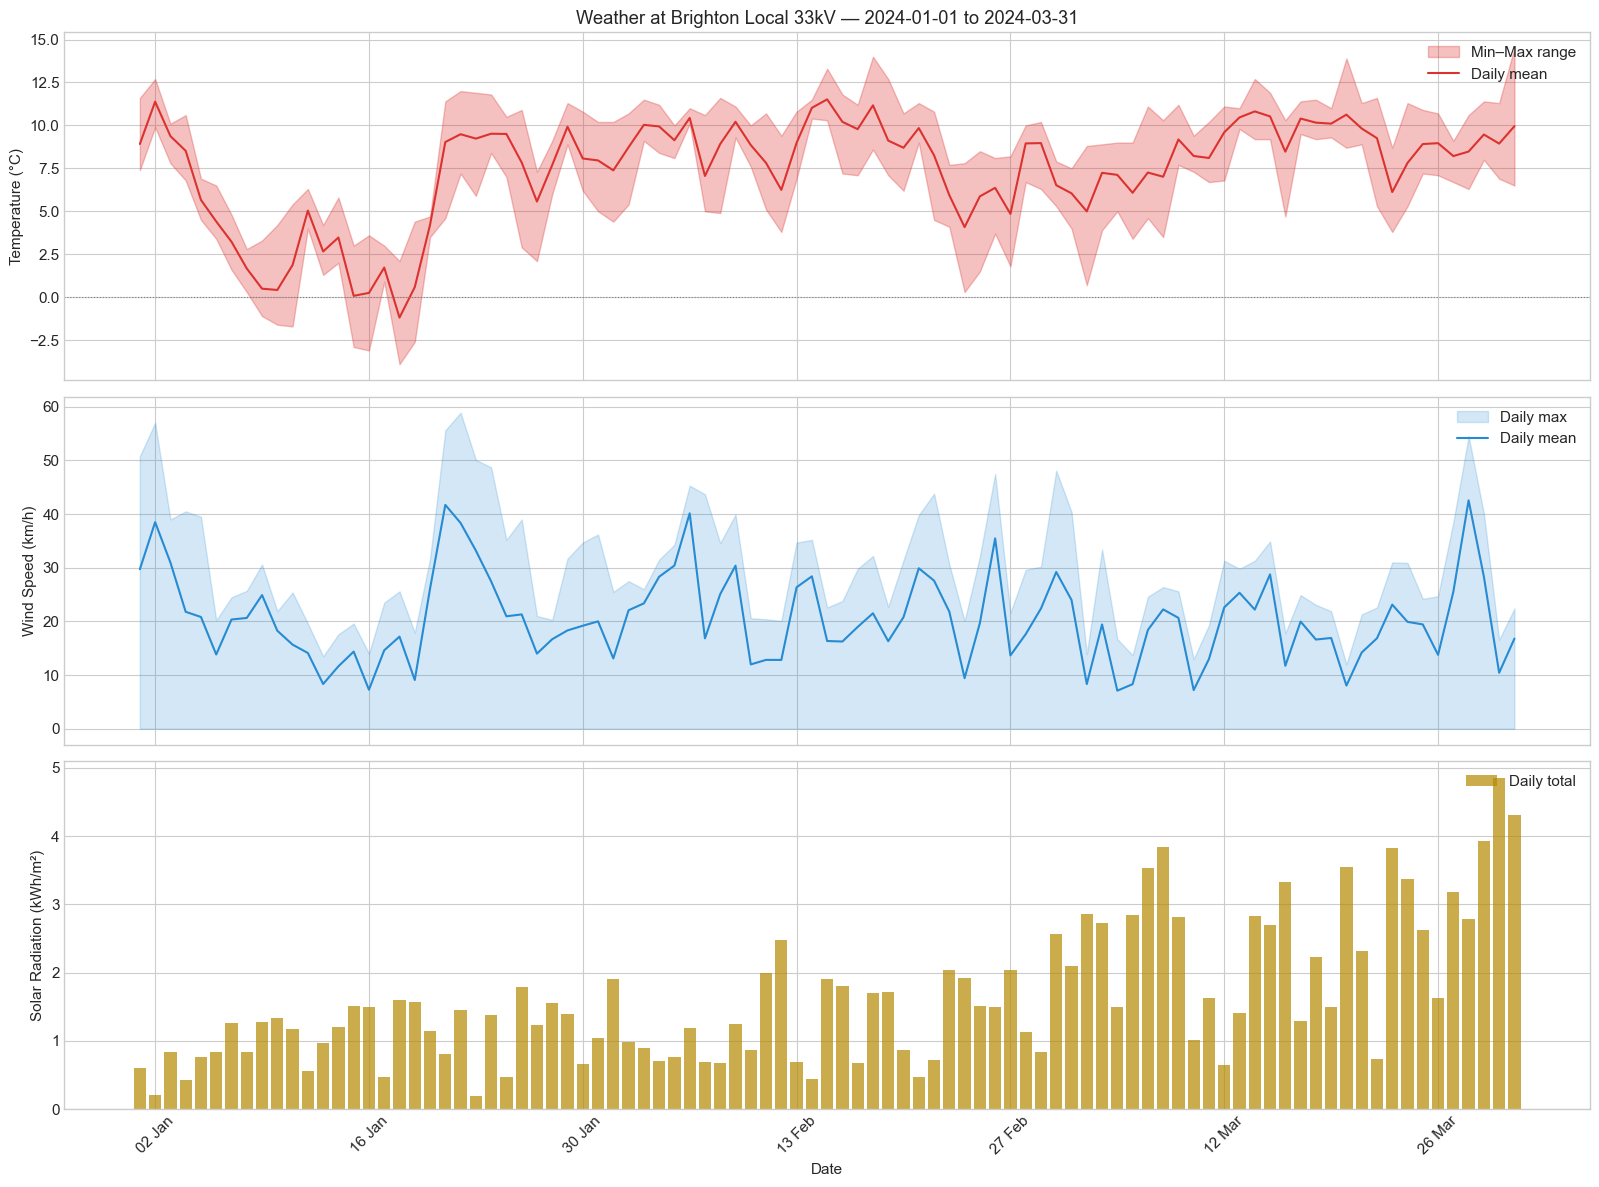

In [6]:
# Temperature, wind speed, and solar radiation over the full period
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Temperature
ax = axes[0]
daily_temp = weather_df["temperature_2m"].resample("D").agg(["min", "mean", "max"])
ax.fill_between(daily_temp.index, daily_temp["min"], daily_temp["max"],
                alpha=0.3, color=COLORS["temperature"], label="Min–Max range")
ax.plot(daily_temp.index, daily_temp["mean"], color=COLORS["temperature"],
        linewidth=1.5, label="Daily mean")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"Weather at {LOCATION_NAME} — {START_DATE} to {END_DATE}")
ax.legend(loc="upper right")
ax.axhline(y=0, color="grey", linestyle=":", linewidth=0.8)

# Wind speed
ax = axes[1]
daily_wind = weather_df["wind_speed_10m"].resample("D").agg(["mean", "max"])
ax.fill_between(daily_wind.index, 0, daily_wind["max"],
                alpha=0.2, color=COLORS["wind"], label="Daily max")
ax.plot(daily_wind.index, daily_wind["mean"], color=COLORS["wind"],
        linewidth=1.5, label="Daily mean")
ax.set_ylabel("Wind Speed (km/h)")
ax.legend(loc="upper right")

# Solar radiation
ax = axes[2]
daily_solar = weather_df["shortwave_radiation"].resample("D").sum() / 1000  # kWh/m²
ax.bar(daily_solar.index, daily_solar.values, color=COLORS["solar"],
       alpha=0.7, width=0.8, label="Daily total")
ax.set_ylabel("Solar Radiation (kWh/m²)")
ax.set_xlabel("Date")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

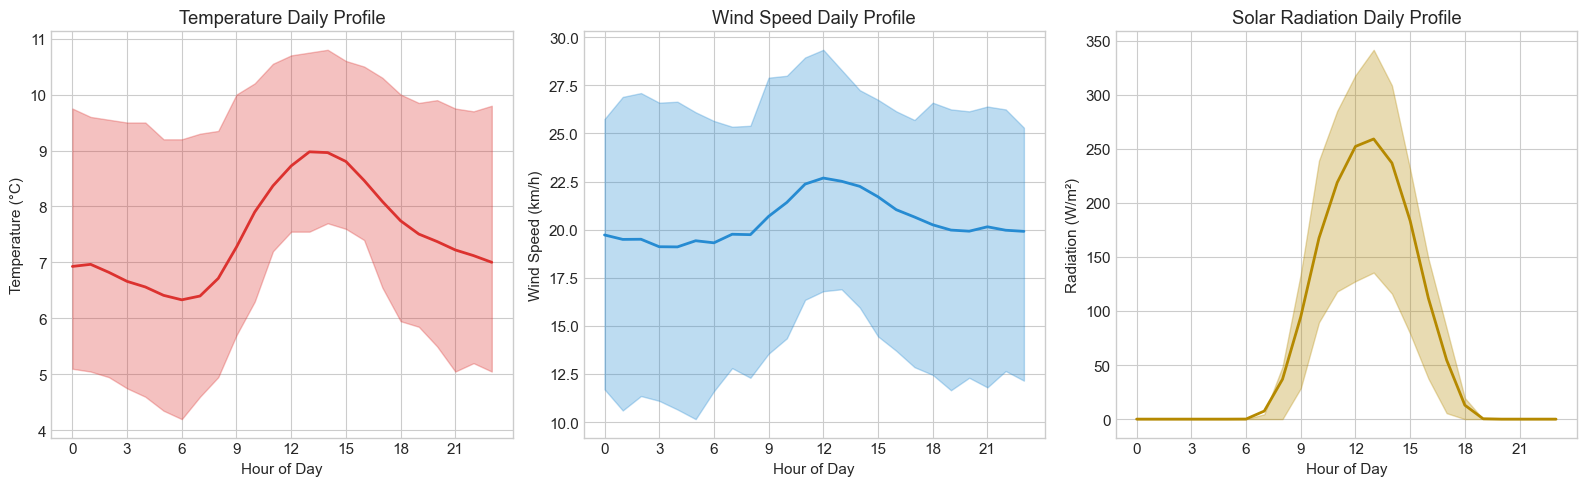

In [7]:
# Average daily profiles — how each variable behaves through the day
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Temperature daily profile
ax = axes[0]
hourly_temp = weather_df.groupby(weather_df.index.hour)["temperature_2m"]
ax.fill_between(range(24), hourly_temp.quantile(0.25), hourly_temp.quantile(0.75),
                alpha=0.3, color=COLORS["temperature"])
ax.plot(range(24), hourly_temp.mean(), color=COLORS["temperature"], linewidth=2)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature Daily Profile")
ax.set_xticks(range(0, 24, 3))

# Wind speed daily profile
ax = axes[1]
hourly_wind = weather_df.groupby(weather_df.index.hour)["wind_speed_10m"]
ax.fill_between(range(24), hourly_wind.quantile(0.25), hourly_wind.quantile(0.75),
                alpha=0.3, color=COLORS["wind"])
ax.plot(range(24), hourly_wind.mean(), color=COLORS["wind"], linewidth=2)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Wind Speed (km/h)")
ax.set_title("Wind Speed Daily Profile")
ax.set_xticks(range(0, 24, 3))

# Solar radiation daily profile
ax = axes[2]
hourly_solar = weather_df.groupby(weather_df.index.hour)["shortwave_radiation"]
ax.fill_between(range(24), hourly_solar.quantile(0.25), hourly_solar.quantile(0.75),
                alpha=0.3, color=COLORS["solar"])
ax.plot(range(24), hourly_solar.mean(), color=COLORS["solar"], linewidth=2)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Radiation (W/m²)")
ax.set_title("Solar Radiation Daily Profile")
ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

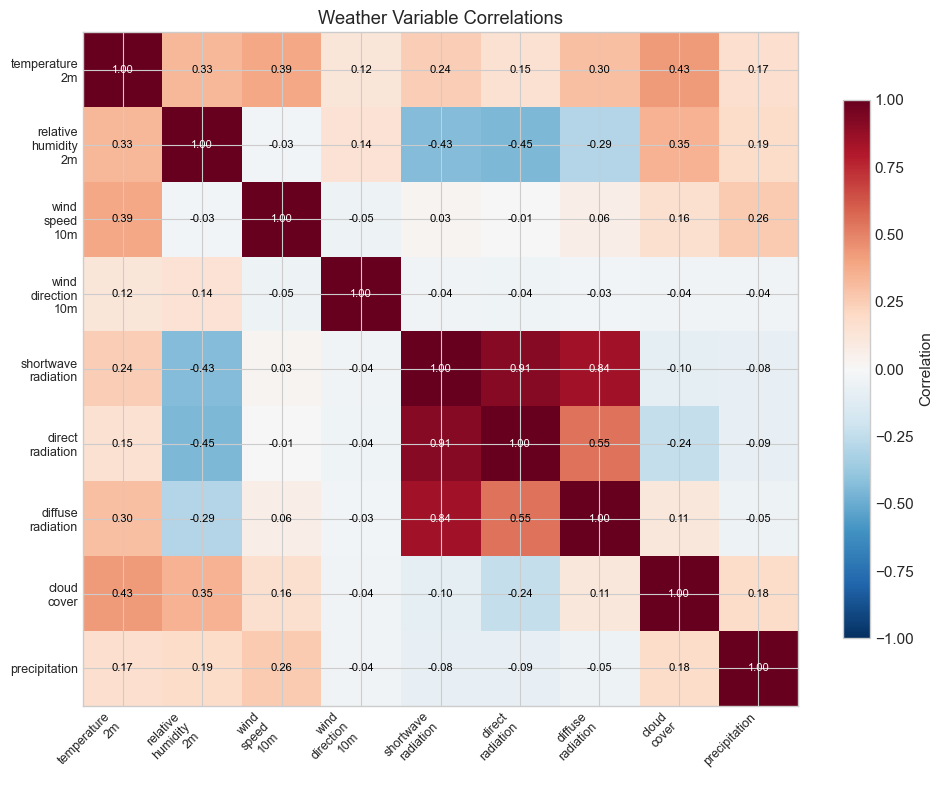

In [8]:
# Correlation matrix between weather variables
fig, ax = plt.subplots(figsize=(10, 8))
corr = weather_df.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
labels = [c.replace("_", "\n") for c in corr.columns]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
ax.set_title("Weather Variable Correlations")
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering for Forecasting

The forecasting notebook uses **half-hourly** (30-minute) load data. Weather data from Open-Meteo is **hourly**. We need to:

1. **Resample** to 30-minute frequency (forward-fill or interpolate)
2. **Derive** additional features: heating degree days, wind power proxy, solar capacity factor
3. **Add lag features** for weather (forecasts are issued ahead of time)

### 5.1 Resample to Half-Hourly

In [9]:
# Resample hourly data to half-hourly using linear interpolation
# This is appropriate for continuous variables like temperature and radiation

weather_30min = weather_df.resample("30min").interpolate(method="linear")

# Forward-fill the last period (interpolate won't extrapolate)
weather_30min = weather_30min.ffill()

print(f"Original:    {len(weather_df)} hourly records")
print(f"Resampled:   {len(weather_30min)} half-hourly records")
print(f"Date range:  {weather_30min.index.min()} to {weather_30min.index.max()}")
print(f"Missing:     {weather_30min.isna().sum().sum()}")

Original:    2184 hourly records
Resampled:   4367 half-hourly records
Date range:  2024-01-01 00:00:00 to 2024-03-31 23:00:00
Missing:     0


### 5.2 Derived Weather Features

Create features that better capture the physical relationship between weather and electricity demand.

In [10]:
# Derived weather features
wx = weather_30min.copy()

# Heating Degree Days (HDD) — proxy for heating demand
# Base temperature 15.5°C is the UK standard for when heating is needed
HDD_BASE = 15.5
wx["hdd"] = np.maximum(HDD_BASE - wx["temperature_2m"], 0)

# Cooling Degree Days (CDD) — proxy for cooling demand (less common in UK)
CDD_BASE = 22.0
wx["cdd"] = np.maximum(wx["temperature_2m"] - CDD_BASE, 0)

# Wind chill — effective temperature accounting for wind
# Simplified formula: wind chill is more pronounced at lower temperatures
wx["wind_chill"] = (
    13.12
    + 0.6215 * wx["temperature_2m"]
    - 11.37 * (wx["wind_speed_10m"] ** 0.16)
    + 0.3965 * wx["temperature_2m"] * (wx["wind_speed_10m"] ** 0.16)
)
# Only apply when temperature < 10°C and wind > 4.8 km/h
mask = (wx["temperature_2m"] >= 10) | (wx["wind_speed_10m"] <= 4.8)
wx.loc[mask, "wind_chill"] = wx.loc[mask, "temperature_2m"]

# Solar capacity factor (normalised 0–1)
# Approximate clear-sky irradiance for Brighton latitude in winter/spring
MAX_IRRADIANCE = 1000  # W/m² (nominal)
wx["solar_capacity_factor"] = (wx["shortwave_radiation"] / MAX_IRRADIANCE).clip(0, 1)

# Wind power proxy (cubic relationship with speed, capped)
# Normalised wind power output using typical turbine cut-in/rated/cut-out
CUT_IN = 10  # km/h
RATED = 45  # km/h
wx["wind_power_proxy"] = np.where(
    wx["wind_speed_10m"] < CUT_IN, 0,
    np.minimum(((wx["wind_speed_10m"] - CUT_IN) / (RATED - CUT_IN)) ** 3, 1)
)

# Temperature rolling averages (captures thermal inertia of buildings)
wx["temp_rolling_6h"] = wx["temperature_2m"].rolling(window=12, min_periods=1).mean()  # 12 × 30min = 6h
wx["temp_rolling_24h"] = wx["temperature_2m"].rolling(window=48, min_periods=1).mean()  # 48 × 30min = 24h

# Day/night indicator based on solar radiation
wx["is_daylight"] = (wx["shortwave_radiation"] > 10).astype(int)

print(f"Derived features created. Total columns: {len(wx.columns)}")
print(f"\nNew features:")
new_cols = [c for c in wx.columns if c not in weather_30min.columns]
for col in new_cols:
    print(f"  {col}: {wx[col].min():.2f} to {wx[col].max():.2f}")

Derived features created. Total columns: 17

New features:
  hdd: 1.00 to 19.40
  cdd: 0.00 to 0.00
  wind_chill: -9.52 to 14.50
  solar_capacity_factor: 0.00 to 0.67
  wind_power_proxy: 0.00 to 1.00
  temp_rolling_6h: -3.27 to 13.63
  temp_rolling_24h: -1.51 to 11.66
  is_daylight: 0.00 to 1.00


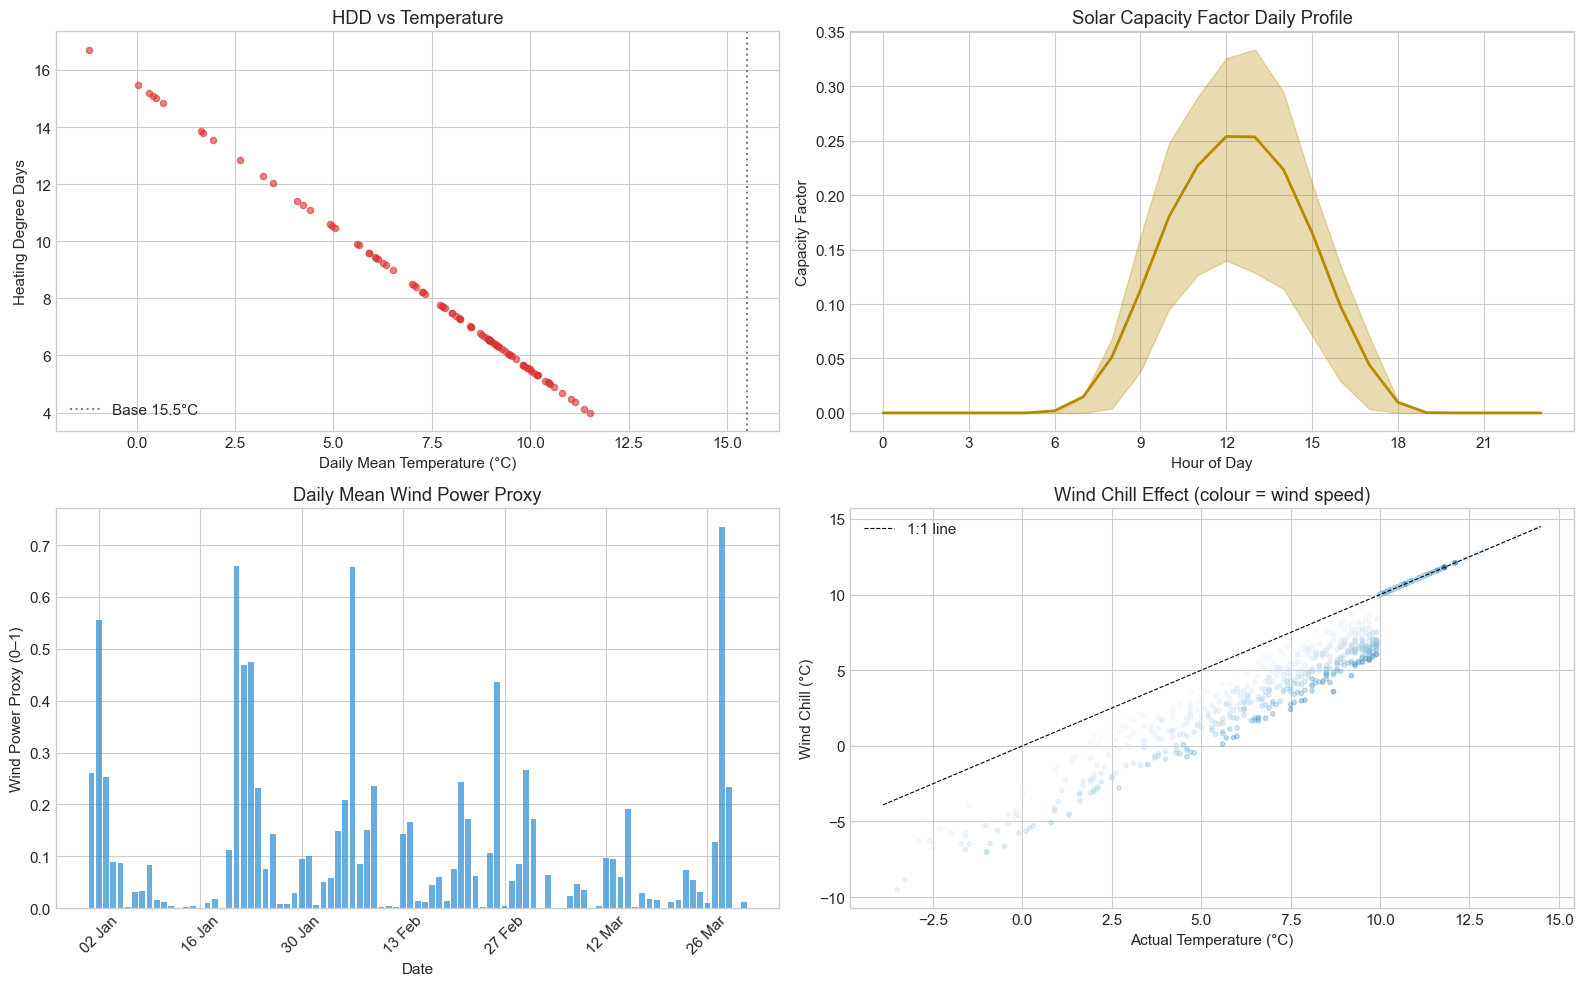

In [11]:
# Visualise derived features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HDD vs Temperature
ax = axes[0, 0]
daily = wx.resample("D").mean()
ax.scatter(daily["temperature_2m"], daily["hdd"], alpha=0.6,
           color=COLORS["temperature"], s=20)
ax.set_xlabel("Daily Mean Temperature (°C)")
ax.set_ylabel("Heating Degree Days")
ax.set_title("HDD vs Temperature")
ax.axvline(x=HDD_BASE, color="grey", linestyle=":", label=f"Base {HDD_BASE}°C")
ax.legend()

# Solar capacity factor — daily profile
ax = axes[0, 1]
hourly_scf = wx.groupby(wx.index.hour)["solar_capacity_factor"]
ax.fill_between(range(24), hourly_scf.quantile(0.25), hourly_scf.quantile(0.75),
                alpha=0.3, color=COLORS["solar"])
ax.plot(range(24), hourly_scf.mean(), color=COLORS["solar"], linewidth=2)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Capacity Factor")
ax.set_title("Solar Capacity Factor Daily Profile")
ax.set_xticks(range(0, 24, 3))

# Wind power proxy over time
ax = axes[1, 0]
daily_wp = wx["wind_power_proxy"].resample("D").mean()
ax.bar(daily_wp.index, daily_wp.values, color=COLORS["wind"], alpha=0.7, width=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Wind Power Proxy (0–1)")
ax.set_title("Daily Mean Wind Power Proxy")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Wind chill vs actual temperature
ax = axes[1, 1]
sample = wx.iloc[::6]  # Every 3 hours for clarity
ax.scatter(sample["temperature_2m"], sample["wind_chill"], alpha=0.3,
           c=sample["wind_speed_10m"], cmap="Blues", s=10)
ax.plot([wx["temperature_2m"].min(), wx["temperature_2m"].max()],
        [wx["temperature_2m"].min(), wx["temperature_2m"].max()],
        "k--", linewidth=0.8, label="1:1 line")
ax.set_xlabel("Actual Temperature (°C)")
ax.set_ylabel("Wind Chill (°C)")
ax.set_title("Wind Chill Effect (colour = wind speed)")
ax.legend()

plt.tight_layout()
plt.show()

### 5.3 Select Features for Export

Choose the most relevant weather features for load forecasting. We keep both raw and derived variables so the forecasting model can learn which are most informative.

In [12]:
# Select features for export
EXPORT_COLUMNS = [
    # Raw weather
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "shortwave_radiation",
    "cloud_cover",
    # Derived features
    "hdd",
    "cdd",
    "wind_chill",
    "solar_capacity_factor",
    "wind_power_proxy",
    "temp_rolling_6h",
    "temp_rolling_24h",
    "is_daylight",
]

weather_features = wx[EXPORT_COLUMNS].copy()

print(f"Export DataFrame: {weather_features.shape[0]} rows × {weather_features.shape[1]} columns")
print(f"Date range: {weather_features.index.min()} to {weather_features.index.max()}")
print(f"Missing values: {weather_features.isna().sum().sum()}")
print(f"\nColumns:")
for col in EXPORT_COLUMNS:
    print(f"  {col}")

Export DataFrame: 4367 rows × 13 columns
Date range: 2024-01-01 00:00:00 to 2024-03-31 23:00:00
Missing values: 0

Columns:
  temperature_2m
  relative_humidity_2m
  wind_speed_10m
  shortwave_radiation
  cloud_cover
  hdd
  cdd
  wind_chill
  solar_capacity_factor
  wind_power_proxy
  temp_rolling_6h
  temp_rolling_24h
  is_daylight


---
## 6. Export for Use in Forecasting Notebook

Save the prepared weather features to CSV. This file can be loaded in `forecasting.ipynb` Section 6.2 (Weather Features) to add weather data to the feature set.

### How to use in the forecasting notebook

In the forecasting notebook's Section 6.2 cell, replace the placeholder with:

```python
# Load weather features prepared in weatherdata.ipynb
weather_features = pd.read_csv("weather_features_brighton.csv", index_col="timestamp", parse_dates=True)

# Merge with the feature DataFrame (aligns on timestamp index)
df = df.join(weather_features, how="left")

# Forward-fill any remaining gaps from index misalignment
df[weather_features.columns] = df[weather_features.columns].ffill()
```

In [13]:
# Export to CSV
output_file = "weather_features_brighton.csv"
weather_features.to_csv(output_file)

print(f"Saved weather features to: {output_file}")
print(f"  Rows: {len(weather_features):,}")
print(f"  Columns: {len(weather_features.columns)}")
print(f"  File size: {pd.io.common.file_exists(output_file) and 'OK' or 'Error'}")

# Preview the final output
weather_features.head(10)

Saved weather features to: weather_features_brighton.csv
  Rows: 4,367
  Columns: 13
  File size: OK


,temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation,cloud_cover,hdd,cdd,wind_chill,solar_capacity_factor,wind_power_proxy,temp_rolling_6h,temp_rolling_24h,is_daylight
timestamp,,,,,,,,,,,,,
2024-01-01 00:00:00,8.40,74.0,34.20,0.0,63.0,7.10,0.0,4.193487,0.0,0.330554,8.400000,8.400000,0
2024-01-01 00:30:00,8.65,71.5,32.65,0.0,54.5,6.85,0.0,4.626601,0.0,0.271019,8.525000,8.525000,0
2024-01-01 01:00:00,8.90,69.0,31.10,0.0,46.0,6.60,0.0,5.061288,0.0,0.219100,8.650000,8.650000,0
2024-01-01 01:30:00,8.60,71.0,32.20,0.0,45.0,6.90,0.0,4.591738,0.0,0.255185,8.637500,8.637500,0
2024-01-01 02:00:00,8.30,73.0,33.30,0.0,44.0,7.20,0.0,4.122097,0.0,0.295028,8.570000,8.570000,0
2024-01-01 02:30:00,7.95,74.5,31.90,0.0,40.5,7.55,0.0,3.760024,0.0,0.244979,8.466667,8.466667,0
2024-01-01 03:00:00,7.60,76.0,30.50,0.0,37.0,7.90,0.0,3.405049,0.0,0.200936,8.342857,8.342857,0
2024-01-01 03:30:00,7.65,75.5,30.05,0.0,64.0,7.85,0.0,3.504593,0.0,0.187992,8.256250,8.256250,0
2024-01-01 04:00:00,7.70,75.0,29.60,0.0,91.0,7.80,0.0,3.604407,0.0,0.175616,8.194444,8.194444,0


---
## Summary

| Step | Detail |
|---|---|
| **Source** | Open-Meteo Historical API (ERA5 reanalysis) |
| **Location** | Brighton (50.82°N, 0.14°W) |
| **Period** | 2024-01-01 to 2024-03-31 |
| **Raw frequency** | Hourly |
| **Output frequency** | Half-hourly (interpolated) |
| **Raw variables** | 9 (temperature, humidity, wind, solar, cloud, precip) |
| **Derived features** | 7 (HDD, CDD, wind chill, solar CF, wind proxy, temp averages, daylight) |
| **Total features** | 13 |

### Alternative data sources

For production use or longer historical periods, consider:

- **[Copernicus CDS (ERA5)](https://cds.climate.copernicus.eu/)** — Full ERA5 reanalysis back to 1940, requires free registration. Use `cdsapi` Python package.
- **[Met Office DataPoint](https://www.metoffice.gov.uk/services/data)** — UK-specific observations and forecasts. Useful for operational forecasting.
- **[MIDAS](https://catalogue.ceda.ac.uk/uuid/220a65615218d5c9cc9e4785a3234bd0)** — Met Office station observations via CEDA. Ground-truth measurements.
- **`ukpyn.integrations.weather`** — Package integration using earthkit-data (under development).